<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_IV_QGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pennylane matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.9 MB/s eta 0:00:00


In [3]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# We will use a 2-qubit system for a simple demonstration
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

print("Quantum Device Ready")

Quantum Device Ready


In [4]:
@qml.qnode(dev, interface="torch")
def quantum_circuit(noise, weights):
    # Encoding latent noise
    for i in range(n_qubits):
        qml.RY(noise[i], wires=i)

    # Trainable Variational Layers (The "Ansatz")
    for i in range(n_qubits):
        qml.RX(weights[i, 0], wires=i)
        qml.RY(weights[i, 1], wires=i)
        qml.RZ(weights[i, 2], wires=i)

    # Entanglement to capture correlations
    qml.CNOT(wires=[0, 1])

    # Return expectation values (the generated "data")
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_qubits, 3))

    def forward(self, x):
        # Apply the quantum circuit to each item in the batch
        return torch.stack([torch.stack(quantum_circuit(i, self.weights)) for i in x])

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
# 1. Initialize models and optimizers
gen = Generator()
disc = Discriminator()
opt_gen = torch.optim.Adam(gen.parameters(), lr=0.01)
opt_disc = torch.optim.Adam(disc.parameters(), lr=0.01)
criterion = nn.BCELoss()

# Tracking history for final plots
d_losses = []
g_losses = []

epochs = 100
batch_size = 5

print("Starting QGAN Training...")

for epoch in range(epochs):
    # --- STEP 1: Train Discriminator on Real Data ---
    real_data = torch.randn(batch_size, n_qubits)
    # Using 0.9 instead of 1.0 (Label Smoothing) for better stability
    real_labels = torch.full((batch_size, 1), 0.9)

    opt_disc.zero_grad()
    out_real = disc(real_data)
    loss_real = criterion(out_real, real_labels)

    # --- STEP 2: Train Discriminator on Fake (Quantum) Data ---
    noise = torch.randn(batch_size, n_qubits)

    # .float() ensures the Double output from PennyLane matches the Float expected by PyTorch
    fake_data = gen(noise).float()
    fake_labels = torch.zeros(batch_size, 1)

    # We detach fake_data so we don't calculate gradients for the Generator yet
    out_fake = disc(fake_data.detach())
    loss_fake = criterion(out_fake, fake_labels)

    d_loss = loss_real + loss_fake
    d_loss.backward()
    opt_disc.step()

    # --- STEP 3: Train Generator (The Adversarial Step) ---
    opt_gen.zero_grad()

    # Generator wants the Discriminator to think fake data is Real (label 1)
    out_gen = disc(fake_data)
    g_loss = criterion(out_gen, torch.ones(batch_size, 1))

    g_loss.backward()
    opt_gen.step()

    # Save progress
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

print("Training Complete!")

Starting QGAN Training...
Epoch 000 | D Loss: 1.4237 | G Loss: 0.6824
Epoch 020 | D Loss: 1.2154 | G Loss: 0.8938
Epoch 040 | D Loss: 1.1142 | G Loss: 1.0581
Epoch 060 | D Loss: 1.1616 | G Loss: 0.9463
Epoch 080 | D Loss: 1.2932 | G Loss: 1.1537
Training Complete!


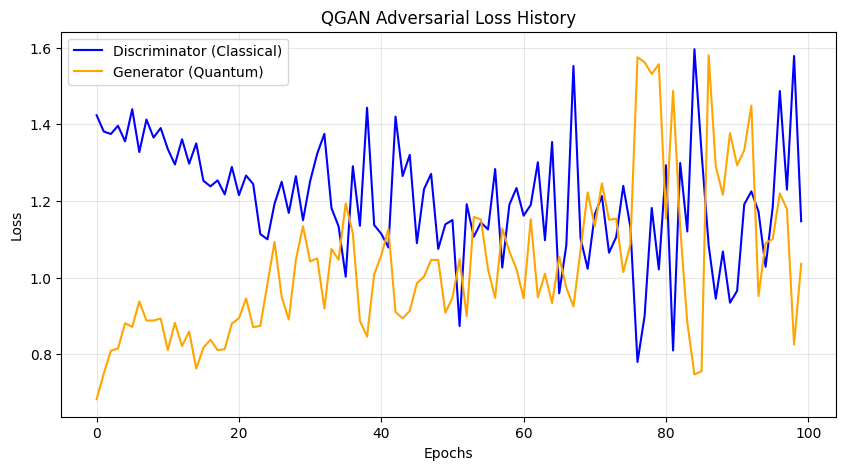

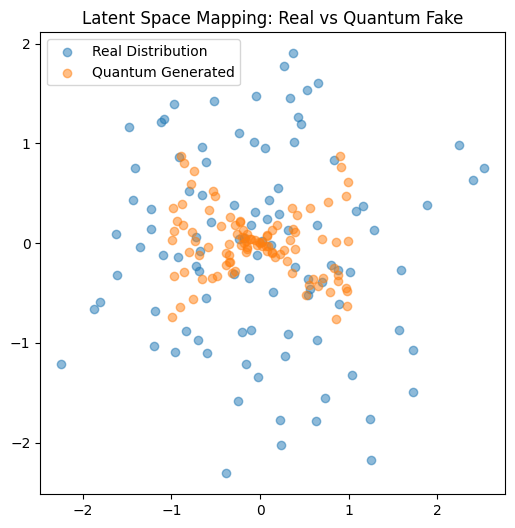

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator (Classical)", color='blue')
plt.plot(g_losses, label="Generator (Quantum)", color='orange')
plt.title("QGAN Adversarial Loss History")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Data Distribution Check
with torch.no_grad():
    test_noise = torch.randn(100, n_qubits)
    generated_samples = gen(test_noise).numpy()
    real_samples = torch.randn(100, n_qubits).numpy()

plt.figure(figsize=(6, 6))
plt.scatter(real_samples[:, 0], real_samples[:, 1], alpha=0.5, label="Real Distribution")
plt.scatter(generated_samples[:, 0], generated_samples[:, 1], alpha=0.5, label="Quantum Generated")
plt.title("Latent Space Mapping: Real vs Quantum Fake")
plt.legend()
plt.show()

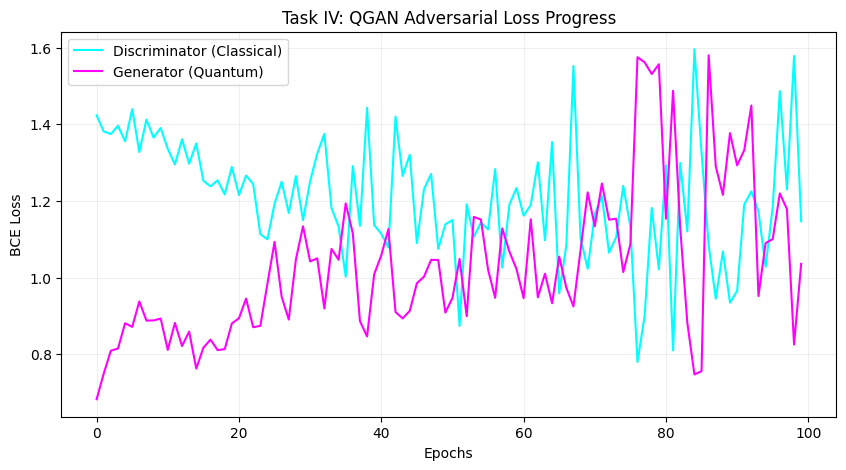

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator (Classical)", color='cyan')
plt.plot(g_losses, label="Generator (Quantum)", color='magenta')
plt.title("Task IV: QGAN Adversarial Loss Progress")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

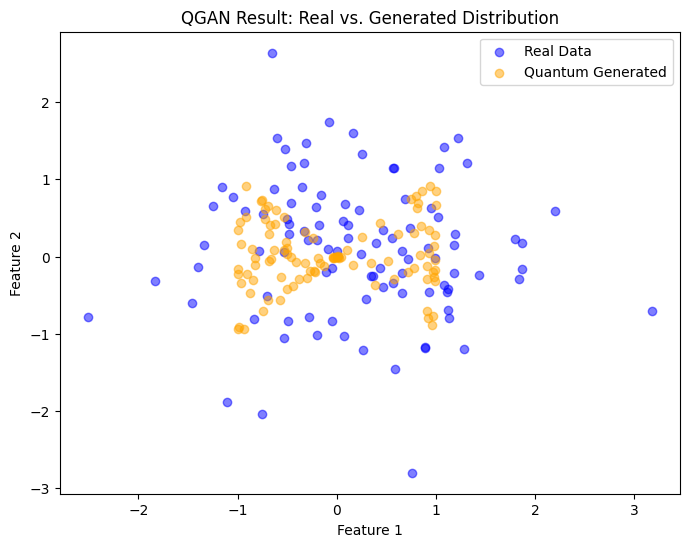

In [10]:
# Generate 100 fake points to compare
with torch.no_grad():
    noise = torch.randn(100, n_qubits)
    generated_data = gen(noise).numpy()
    real_data_sample = torch.randn(100, n_qubits).numpy()

plt.figure(figsize=(8, 6))
plt.scatter(real_data_sample[:, 0], real_data_sample[:, 1], alpha=0.5, label="Real Data", color='blue')
plt.scatter(generated_data[:, 0], generated_data[:, 1], alpha=0.5, label="Quantum Generated", color='orange')
plt.title("QGAN Result: Real vs. Generated Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()